# NB4- Transfer learning
## Goal
- Use a pretrained model for 12-class wildlife image classification.
- Use **MobileNetV2** because it is lighter and faster than ResNet, strong for image classificatio.

## Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
import matplotlib.pyplot as plt

## Set Parameters

In [2]:
data_dir = "C:/Projects/06_WildLife_Image_Classification/Wildlife_images"
img_size = (224,224)
batch_size = 32
num_classes = 12
epochs = 10


## Create data generators


In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode= 'categorical',
    subset="validation",
    shuffle=False
)

Found 2134 images belonging to 12 classes.
Found 530 images belonging to 12 classes.


## Load pretrained MoibleNetV2 base

In [5]:

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 15s 2us/step


# Build the transfer learning model

In [6]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

## Compile the model

In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Callbacks

In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_mobilenet_model.keras",
    monitor= "val_accuracy",
    mode="max",
    save_best_only=True
)

## Train the model

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9972 - loss: 0.0121 - val_accuracy: 0.9981 - val_loss: 0.0033
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 46s 681ms/step - accuracy: 0.9977 - loss: 0.0088 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 48s 714ms/step - accuracy: 0.9995 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 6.1966e-04
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 49s 731ms/step - accuracy: 0.9991 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 5.3501e-04
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9991 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 3.6763e-04
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 41s 618ms/step - accuracy: 0.9991 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 1.8242e-04
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 42s 622ms/step - accuracy: 0.9986 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 1.4096e-04
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 43s 642ms/step - accuracy: 1.0000 - loss: 0.

## PLot Accuracy

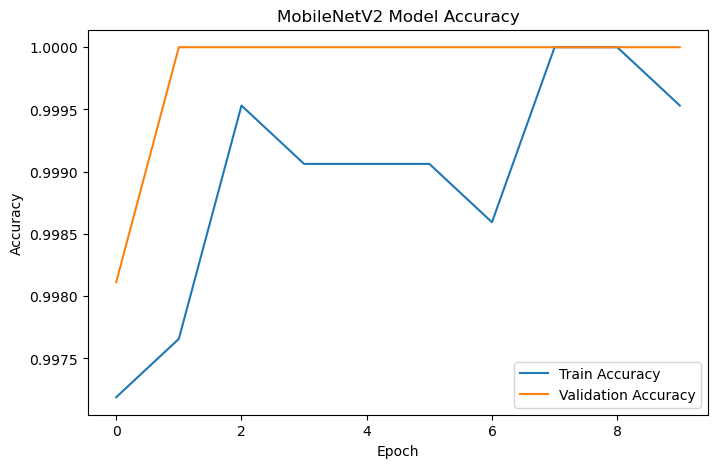

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Plot loss

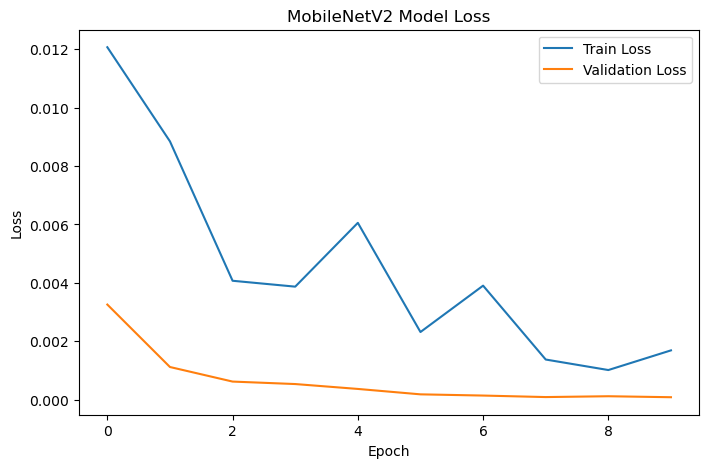

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Evaluate the model

In [15]:
val_loss, val_acc = model.evaluate(val_data)
print(f"Validation Loss: {val_loss: .4f}")
print(f"Validation Accuracy: {val_acc: .4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 388ms/step - accuracy: 1.0000 - loss: 8.3871e-05
Validation Loss:  0.0001
Validation Accuracy:  1.0000


## Confusion Matrix

17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 354ms/step


<Figure size 1000x800 with 0 Axes>

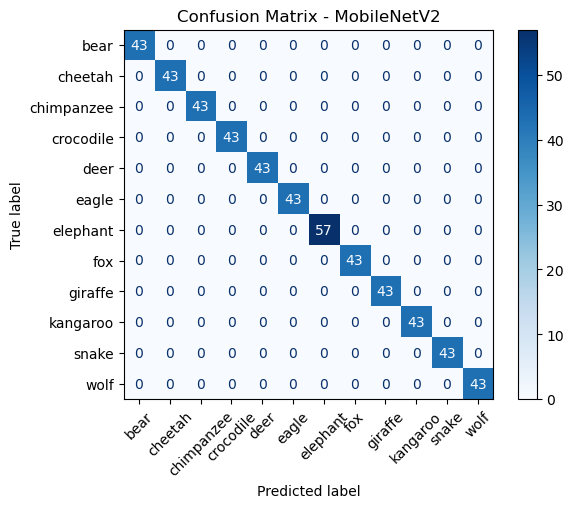

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

val_data.reset()
pred_probs = model.predict(val_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_data.classes

cm = confusion_matrix(true_classes, pred_classes)

class_names = list(val_data.class_indices.keys())

plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

## Classification Report

In [20]:
from sklearn.metrics import classification_report

print(classification_report(true_classes, pred_classes, target_names=class_names))

              precision    recall  f1-score   support

        bear       1.00      1.00      1.00        43
     cheetah       1.00      1.00      1.00        43
  chimpanzee       1.00      1.00      1.00        43
   crocodile       1.00      1.00      1.00        43
        deer       1.00      1.00      1.00        43
       eagle       1.00      1.00      1.00        43
    elephant       1.00      1.00      1.00        57
         fox       1.00      1.00      1.00        43
     giraffe       1.00      1.00      1.00        43
    kangaroo       1.00      1.00      1.00        43
       snake       1.00      1.00      1.00        43
        wolf       1.00      1.00      1.00        43

    accuracy                           1.00       530
   macro avg       1.00      1.00      1.00       530
weighted avg       1.00      1.00      1.00       530

